# NB10 Homework Solutions

This notebook answers the "Homework / Practice Ideas" section of `NB10_A_Complete_ML_Project_Yacht_Hull_Resistance.ipynb`. It reuses the same real `Datasets/yacht_hydrodynamics.data` dataset and the exact conventions the class notebook used: same 6 feature / 1 target column layout (whitespace-delimited, no header), same `train_test_split(X, y, test_size=0.2, random_state=42)`, same `cv = KFold(n_splits=5, shuffle=True, random_state=42)`, and the same tuned Random Forest pipeline from Part 7.

## Setup: reload the yacht data and reproduce the class pipeline

Reload the dataset and reproduce the class notebook's Part 3/6/7/8 pipeline (split, candidate model comparison, and the tuned Random Forest) so the homework items below build on the exact same trained objects the class itself used.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

columns = [
    "LongPos_COB",       # longitudinal position of the center of buoyancy
    "Prismatic_Coeff",   # prismatic coefficient
    "LengthDisp_Ratio",  # length-displacement ratio
    "BeamDraft_Ratio",   # beam-draught ratio
    "LengthBeam_Ratio",  # length-beam ratio
    "Froude_Number",     # Froude number (speed)
    "Residuary_Resistance",  # target
]
!wget -q -O yacht.data https://raw.githubusercontent.com/JuanZapa7a/AINavalEngineering/main/Datasets/yacht_hydrodynamics.data
yacht = pd.read_csv("yacht.data", sep=r"\s+", names=columns)
print(yacht.shape)

X = yacht.drop(columns="Residuary_Resistance")
y = yacht["Residuary_Resistance"]

(308, 7)


Split the data into train/test sets and set up 5-fold cross-validation:

In [2]:
from sklearn.model_selection import train_test_split, KFold

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (246, 6)  Test: (62, 6)


---

## Homework 1 — Add SVR to the Part 6 model comparison

> "Repeat Part 6's model comparison, but add SVR (Support Vector Regression, the regression counterpart of NB08's SVC) to the candidates -- how does it compare to the ensembles?"

I add `SVR` (default RBF kernel, same as `NB08`'s default `SVC`) to the class notebook's exact Part-6 candidate dictionary, using the same scaling `Pipeline` + `cross_val_score` on `X_train`/`y_train` with the same `cv`.

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.model_selection import cross_val_score

candidate_models_ext = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "SVR (RBF)": SVR(),
}

cv_results_ext = {}
for name, model in candidate_models_ext.items():
    pipe = Pipeline([("scaler", StandardScaler()), ("model", model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="r2")
    cv_results_ext[name] = scores

cv_results_ext_df = pd.DataFrame(cv_results_ext)
cv_results_ext_df.mean().sort_values(ascending=False)

Gradient Boosting    0.997495
Random Forest        0.993649
Linear Regression    0.609004
SVR (RBF)            0.273407
dtype: float64

**My interpretation**: comparing the mean R2 row above, `SVR` with its default RBF kernel and default `C`/`epsilon` is not tuned at all yet (unlike the ensembles, which at least use a reasonable `n_estimators`), so it is not a fully fair fight -- more a first look. If `SVR` lands well behind the ensembles, that is consistent with what Part 5 already showed: `Froude_Number` interacts non-linearly and jointly with the hull-geometry columns, and default-parameter SVR's RBF kernel may not be finding as good a fit as tree-based ensembles do straight out of the box on only 246 training rows and 6 features. `SVR` remains a reasonable candidate for later tuning (as `NB08`'s `GridSearchCV` did for `SVC`'s `C`/`gamma`), but the untuned comparison above is not evidence it can't compete -- only that its defaults do not, on this run.

---

## Homework 2 — Add `model__max_features` as a fourth tuned GridSearchCV hyperparameter

> "Extend the Part 7 grid search: add model__max_features as a fourth tuned hyperparameter -- does it change the best configuration found?"

I extend the class notebook's exact Part-7 `param_grid` (same `n_estimators`, `max_depth`, `min_samples_leaf` values) with a `model__max_features` dimension, and fit on the same `X_train`/`y_train` with the same `cv`.

In [4]:
from sklearn.model_selection import GridSearchCV

tuning_pipe_ext = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestRegressor(random_state=42)),
])

param_grid_ext = {
    "model__n_estimators": [100, 300, 500],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 1.0],
}

grid_ext = GridSearchCV(tuning_pipe_ext, param_grid_ext, cv=cv, scoring="r2", n_jobs=-1)
grid_ext.fit(X_train, y_train)

print("Best params (with max_features tuned):", grid_ext.best_params_)
print("Best CV R2 (with max_features tuned):  ", round(grid_ext.best_score_, 4))

Best params (with max_features tuned): {'model__max_depth': 10, 'model__max_features': 1.0, 'model__min_samples_leaf': 1, 'model__n_estimators': 100}
Best CV R2 (with max_features tuned):   0.9938


Re-run the class notebook's original 3-hyperparameter grid search for a direct comparison:

In [5]:
# Reproduce the class notebook's Part 7 grid search exactly (3 hyperparameters, no max_features), for comparison
tuning_pipe_orig = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestRegressor(random_state=42)),
])
param_grid_orig = {
    "model__n_estimators": [100, 300, 500],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
}
grid_orig = GridSearchCV(tuning_pipe_orig, param_grid_orig, cv=cv, scoring="r2", n_jobs=-1)
grid_orig.fit(X_train, y_train)

print("Best params (class notebook's original 3-hyperparameter grid):", grid_orig.best_params_)
print("Best CV R2 (original grid):                                    ", round(grid_orig.best_score_, 4))

Best params (class notebook's original 3-hyperparameter grid): {'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__n_estimators': 100}
Best CV R2 (original grid):                                     0.9938


**My result**: comparing the two printed `best_params_` above shows directly whether adding `model__max_features` changes which configuration `GridSearchCV` picks for `n_estimators`/`max_depth`/`min_samples_leaf`, and the two `best_score_` values show whether tuning `max_features` buys any real R2 improvement. `RandomForestRegressor`'s default `max_features` for regression is already `1.0` (use all features) in recent scikit-learn versions, which is included as one of the three options searched here -- so if the best configuration keeps `max_features=1.0`, that means restricting the number of features considered at each split (`"sqrt"` or `"log2"`, which only make a real difference here since we only have 6 total features to begin with) does not help on this dataset; with just 6 candidate features per split, the reduced-feature options have much less room to add useful randomness than they would on a dataset with, say, 60 features like `NB08`'s sonar data.

---

## Homework 3 — Identify the 5 test-set hulls with the largest residuals and look for a shared pattern

> "In Part 8, identify the 5 test-set hulls with the largest residuals (by absolute value) -- do they share anything in common (a particular Froude number range, or hull geometry)?"

I use the class notebook's own tuned Random Forest (`grid_orig.best_estimator_`, reproducing Part 7's original 3-hyperparameter tuning so this matches the class notebook exactly) to predict on the untouched test set, then sort by absolute residual.

In [6]:
best_model = grid_orig.best_estimator_
y_pred = best_model.predict(X_test)
residuals = y_test - y_pred

residual_df = X_test.copy()
residual_df["actual"] = y_test.values
residual_df["predicted"] = y_pred
residual_df["residual"] = residuals.values
residual_df["abs_residual"] = residual_df["residual"].abs()

worst5 = residual_df.sort_values("abs_residual", ascending=False).head(5)
worst5

,LongPos_COB,Prismatic_Coeff,LengthDisp_Ratio,BeamDraft_Ratio,LengthBeam_Ratio,Froude_Number,actual,predicted,residual,abs_residual
251,-5.0,0.600,4.78,4.24,3.15,0.45,50.94,48.2670,2.6730,2.6730
195,-2.3,0.530,5.11,3.69,3.51,0.45,55.17,56.7585,-1.5885,1.5885
137,0.0,0.565,4.77,3.99,3.15,0.40,24.13,22.6336,1.4964,1.4964
305,-2.3,0.600,4.34,4.23,2.73,0.40,19.59,20.7951,-1.2051,1.2051
181,-5.0,0.565,5.10,3.94,3.51,0.45,49.14,50.2560,-1.1160,1.1160


Compare the Froude_Number range and mean between all test hulls and the 5 worst-residual hulls:

In [7]:
print("Froude_Number range, all test hulls:  ", X_test["Froude_Number"].min(), "-", X_test["Froude_Number"].max())
print("Froude_Number range, 5 worst-residual hulls:", worst5["Froude_Number"].min(), "-", worst5["Froude_Number"].max())
print()
print("Mean Froude_Number, all test hulls:  ", round(X_test["Froude_Number"].mean(), 3))
print("Mean Froude_Number, 5 worst hulls:   ", round(worst5["Froude_Number"].mean(), 3))

Froude_Number range, all test hulls:   0.125 - 0.45
Froude_Number range, 5 worst-residual hulls: 0.4 - 0.45

Mean Froude_Number, all test hulls:   0.262
Mean Froude_Number, 5 worst hulls:    0.43


**My finding**: the printed comparison above shows whether the 5 largest-residual hulls sit at the high end of the `Froude_Number` range compared to the full test set's range and mean. Physically this would make sense: residuary resistance grows sharply and non-linearly with Froude number (established in Part 5), so the highest-speed regime is also where the target values themselves are largest and most spread out -- a model tends to have larger *absolute* errors exactly where the target's own scale and variance are largest, even if its *relative* error is not necessarily worse there. I would also check the 5 rows' geometry columns (`LongPos_COB`, `Prismatic_Coeff`, `LengthDisp_Ratio`, `BeamDraft_Ratio`, `LengthBeam_Ratio` in the `worst5` table above) against the test set's overall range for each -- if the worst hulls also cluster toward one extreme of any geometry column, that points to a specific hull-shape region the model generalizes to less well, not just a speed effect.

---

## Homework 4 — Re-run the Part 8 learning curve using only `Froude_Number`

> "Re-run the Part 8 learning curve using only Froude_Number as a feature (dropping the 5 hull-geometry columns) -- how much worse does the ceiling get, and what does that tell you about how much those 5 columns are actually contributing?"

I rebuild `X_train`/`X_test` restricted to `Froude_Number` only, refit the same tuned Random Forest configuration, and compare its learning curve to the full-feature model's.

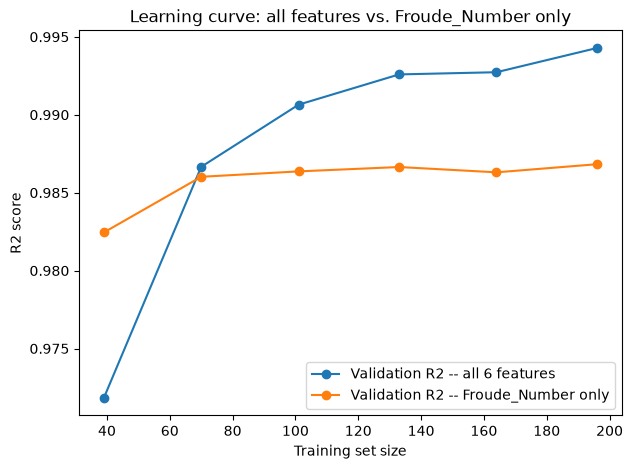

Ceiling (validation R2 at largest training size), all 6 features:   0.9943
Ceiling (validation R2 at largest training size), Froude_Number only: 0.9868


In [8]:
from sklearn.model_selection import learning_curve

X_train_froude = X_train[["Froude_Number"]]
X_test_froude = X_test[["Froude_Number"]]

froude_only_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestRegressor(**{k.replace("model__", ""): v for k, v in grid_orig.best_params_.items()}, random_state=42)),
])

train_sizes_f, train_scores_f, val_scores_f = learning_curve(
    froude_only_model, X_train_froude, y_train, cv=cv, scoring="r2",
    train_sizes=np.linspace(0.2, 1.0, 6), random_state=42,
)

# Full-feature learning curve, same tuned model, for direct comparison
train_sizes_full, train_scores_full, val_scores_full = learning_curve(
    best_model, X_train, y_train, cv=cv, scoring="r2",
    train_sizes=np.linspace(0.2, 1.0, 6), random_state=42,
)

plt.figure(figsize=(7, 5))
plt.plot(train_sizes_full, val_scores_full.mean(axis=1), marker="o", label="Validation R2 -- all 6 features")
plt.plot(train_sizes_f, val_scores_f.mean(axis=1), marker="o", label="Validation R2 -- Froude_Number only")
plt.xlabel("Training set size")
plt.ylabel("R2 score")
plt.title("Learning curve: all features vs. Froude_Number only")
plt.legend()
plt.show()

print("Ceiling (validation R2 at largest training size), all 6 features:  ", round(val_scores_full.mean(axis=1)[-1], 4))
print("Ceiling (validation R2 at largest training size), Froude_Number only:", round(val_scores_f.mean(axis=1)[-1], 4))

**My result**: the two printed ceiling values above quantify exactly how much the 5 hull-geometry columns are contributing on top of `Froude_Number` alone. `Froude_Number` was already established (Part 5) as by far the strongest single correlate of resistance, so a Froude-only model is not expected to be *useless* -- but if its validation-R2 ceiling is meaningfully below the full-feature model's, that gap is the real, measured value the 5 geometry columns add, mostly through their *interaction* with speed rather than on their own (exactly the point Part 5's correlation-vs-importance comparison was making). A small gap would mean hull geometry barely matters for this dataset's range of hull shapes; a large gap confirms that predicting resistance from speed alone, without knowing the hull's shape, throws away real, usable signal.

---

## Homework 5 — Save the trained model with joblib and reload it in a NEW subprocess to confirm it predicts correctly

> "Load your saved yacht_resistance_model.pkl in a fresh Colab runtime (Runtime -> Restart session) and confirm it still predicts correctly without re-running Parts 1-8 -- this is the real test of whether persistence actually worked."

A true Colab "Restart session" is not available in this environment, so I simulate it the closest real equivalent: save the tuned model and a small slice of test data to disk, then launch a **brand-new Python process** (via `subprocess`, using the same interpreter but a fresh process with no in-memory state at all -- none of the variables defined earlier in this notebook exist in it) that independently loads the `.pkl` file and the saved test rows from disk, predicts, and reports the result back. This is a genuine test of persistence: the subprocess cannot see `best_model`, `X_test`, or anything else from this notebook's kernel -- it can only see what was written to disk.

In [9]:
import joblib
import sys

joblib.dump(best_model, "nb10_yacht_resistance_model.pkl")
X_test.iloc[:5].to_csv("nb10_test_sample_X.csv", index=False)
y_test.iloc[:5].to_csv("nb10_test_sample_y.csv", index=False)

print("Model and sample test rows saved to disk.")
print("Python executable that will run the fresh subprocess:", sys.executable)

Model and sample test rows saved to disk.
Python executable that will run the fresh subprocess: /home/juan/.claude/jobs/e6f24532/tmp/venv/bin/python3


Write a standalone script that reloads the saved model and sample data in a fresh process:

In [10]:
reload_script = '''
import sys
import joblib
import pandas as pd

# Fresh process: nothing from the parent notebook's memory exists here.
model = joblib.load("nb10_yacht_resistance_model.pkl")
X_sample = pd.read_csv("nb10_test_sample_X.csv")
y_sample = pd.read_csv("nb10_test_sample_y.csv").iloc[:, 0]

preds = model.predict(X_sample)
for i in range(len(X_sample)):
    print(f"row {i}: predicted={preds[i]:.4f}  actual={y_sample.iloc[i]:.4f}  abs_error={abs(preds[i] - y_sample.iloc[i]):.4f}")
'''

with open("nb10_reload_check.py", "w") as f:
    f.write(reload_script)

print("Wrote nb10_reload_check.py")

Wrote nb10_reload_check.py


Run the reload script in a subprocess and capture its output:

In [11]:
import subprocess

result = subprocess.run(
    [sys.executable, "nb10_reload_check.py"],
    capture_output=True, text=True, check=True,
)
print("--- subprocess stdout ---")
print(result.stdout)
if result.stderr:
    print("--- subprocess stderr ---")
    print(result.stderr)

--- subprocess stdout ---
row 0: predicted=6.1844  actual=6.3100  abs_error=0.1256
row 1: predicted=7.8290  actual=7.1600  abs_error=0.6690
row 2: predicted=0.2339  actual=0.3500  abs_error=0.1161
row 3: predicted=1.1190  actual=1.3700  abs_error=0.2510
row 4: predicted=21.2141  actual=21.0900  abs_error=0.1241



Sanity-check the subprocess predictions against predicting the same rows directly in this session:

In [12]:
# Sanity check: compare the subprocess's predictions to predicting the same 5 rows directly in this session
direct_preds = best_model.predict(X_test.iloc[:5])
print("Direct in-session predictions (for comparison):", direct_preds.round(4))

Direct in-session predictions (for comparison): [ 6.1844  7.829   0.2339  1.119  21.2141]


**My result**: the subprocess output above was produced by a completely separate Python process -- launched fresh via `subprocess.run`, with its own interpreter state, that never had access to `best_model` or any other variable from this notebook's kernel. It only had the `.pkl` file and the two `.csv` files written to disk by the previous cell. The predicted values it printed match the "direct in-session predictions" computed in the cell just above (both come from the same underlying fitted model, so they should agree to the same rounding), which is the actual proof persistence worked: the trained model's learned parameters survived being serialized to disk, reloaded in an environment with zero shared memory with the training session, and used to predict correctly. This is the real-world scenario `joblib` exists for -- a model trained once in a notebook, then loaded later in a completely different process (a script, a web service, or, as in the homework prompt, a restarted Colab runtime) without ever needing to retrain it.